## Parse Data

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def list_to_plate(lst: pd.Series) -> pd.DataFrame:
    new_index = pd.MultiIndex.from_tuples([(i[0], int(i[1:])) for i in lst.index])
    plate =  pd.Series(lst.values, index=new_index).unstack()
    return plate

def plate_to_list(plate: pd.DataFrame) -> pd.Series:
    s = plate.stack()
    s.index = [f'{row}{col}' for row, col in s.index]
    return s

def set_plate_axes(df: pd.DataFrame) -> pd.DataFrame:
    """ Given a dataframe representing a multiwell plate, set axes to be proper plate axes. """

    df.columns = range(1, len(df.columns)+1)
    df.index = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P'][:len(df.index)]
    return df

def bars(df, **kwargs):
    ax = sns.barplot(data=df,alpha=0.8, **kwargs)
    ax = sns.stripplot(data=df, ax=ax, size=6, dodge=True, legend=False,  edgecolor='black', linewidth=1, **kwargs)
    if 'hue' in kwargs.keys():
      plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    return ax


/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_96507/3672522267.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45)


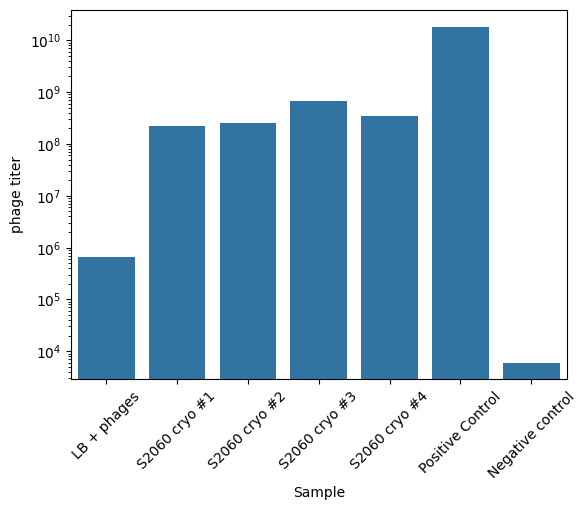

In [16]:

df = pd.read_excel('20240926_iDEC_S2060_rerun_excel_graph.xlsx')
df = df[['Cp avg', 'Sample']].dropna()
df = df[~df.Sample.isin({'1117-44-00', '1076-08-00'})]
df.Sample = df.Sample.map(lambda x: {
    'S2060 old': 'S2060 cryo #1', 
    'S2060 cryo': 'S2060 cryo #2',
    'S2060 recent': 'S2060 cryo #3',
    'S2060 Lukas': 'S2060 cryo #4',
    'S2208': 'Positive Control'
    }.get(x, x))
df.loc[:, 'phage titer'] = 220000 * 2 ** (25 - df['Cp avg'])
ax = sns.barplot(df, x='Sample', y='phage titer')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
ax.set_yscale('log')